In [ ]:
# Segundo notebook
# Con el master CSV que hemos generado, vamos a proceder a entrenar nuestro modelo aqui ^.^

# 02 — Entrenamiento: Regresión de Edad

**¿Qué hace este notebook?**

Predecir la **edad de un paciente** a partir de su radiografía de tórax.
Esto es regresión: la salida no es una categoría (sano/enfermo) sino un número
continuo (ej: 47.3 años).

Reutilizamos el backbone DenseNet121 que entrenó el NB02 de clasificación.
Ese backbone ya sabe 'leer' radiografías; nosotros solo le cambiamos la cabeza
final para que ahora prediga números en lugar de probabilidades.

**¿Por qué funciona?**
El envejecimiento deja huellas visibles en una radiografía: densidad ósea,
calcificaciones, tamaño del corazón, cambios en la columna. La red aprende
a leer esas señales para estimar la edad.

**Dataset:** NIH Chest X-Rays — su metadata tiene columna `Patient Age`.
Solo usamos vistas PA (posteroanterior), igual que el NB02.

**Prerequisito:** `02_Backbone_Clasificacion.ipynb` debe haber corrido
y guardado `backbone_densenet121.h5` en Drive/Vena/checkpoints/

**Archivos que produce:**
- `Vena/checkpoints/mejor_modelo_regresion.h5`
- `Vena/checkpoints/curvas_entrenamiento_regresion.png`
- `Vena/checkpoints/test_regresion.csv` (para que NB03 lo use)

---
**Antes de ejecutar:** Entorno de ejecucion → Cambiar tipo → GPU (T4)

## Celda 1 — Verificacion de GPU

Sin GPU el entrenamiento tomaria horas en lugar de minutos.
Esta celda confirma que Colab asigno una antes de continuar.

Si dice 'No se encontro GPU': ir a
Entorno de ejecucion → Cambiar tipo de entorno → Acelerador: T4 GPU → Guardar.

In [ ]:
import tensorflow as tf

# list_physical_devices('GPU') devuelve la lista de GPUs disponibles.
# Si la lista esta vacia, Colab no asigno GPU — detener aqui.
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU encontrada: {gpus[0].name}")
    print("El entrenamiento usara aceleracion por GPU.")
else:
    raise SystemError(
        "No se encontro GPU. Detener aqui y cambiar el entorno de ejecucion."
    )

GPU encontrada: /physical_device:GPU:0
El entrenamiento usara aceleracion por GPU.


## Celda 2 — Montar Google Drive y definir rutas

Colab corre en una maquina virtual en la nube sin acceso a Drive por defecto.
Esta celda conecta esa maquina con el Drive del equipo.

Al ejecutar aparecera un dialogo pidiendo permisos.
Aceptar con la cuenta que tiene acceso a la carpeta compartida Vena.

Usamos `pathlib.Path` para construir rutas de forma segura — funciona igual
en Windows, Mac y Linux sin importar quien ejecute el notebook.

In [ ]:
from google.colab import drive
from pathlib import Path

# Montar Drive en la ruta estandar de Colab
drive.mount("/content/drive")

# ── Raiz del proyecto ──────────────────────────────────────────────────────────
# Carpeta compartida entre todos los integrantes del equipo.
# Todas las demas rutas se derivan de aqui para que el codigo funcione
# sin importar que cuenta de Google ejecute el notebook.
ruta_vena        = Path("/content/drive/MyDrive/Vena")
ruta_notebooks   = ruta_vena / "Notebooks"
ruta_datasets    = ruta_notebooks / "Datasets"

# ── Rutas especificas ──────────────────────────────────────────────────────────

# CSV del NIH — tiene Patient Age, Patient ID, View Position, Finding Labels
ruta_nih_csv     = ruta_datasets / "dataset_nih_resized" / "Data_Entry_2017.csv"

# ZIP con las imagenes del NIH — se descomprimira a disco local en la siguiente celda
# Las imagenes estan en Drive como .zip para ahorrar espacio de almacenamiento
ruta_nih_zip     = ruta_datasets / "nih_resized_224.zip"

# Ruta LOCAL donde quedaran las imagenes tras descomprimir (en la VM de Colab)
# /content/ es el disco local de la sesion — acceso MUCHO mas rapido que Drive
ruta_nih_imgs    = Path("/content/nih_resized_224/nih_resized_224")

# Carpeta donde viven los modelos guardados
ruta_checkpoints = ruta_vena / "checkpoints"

# Backbone entrenado por el NB02 — lo vamos a reutilizar
ruta_backbone    = ruta_checkpoints / "backbone_densenet121.h5"

# Donde guardaremos nuestro modelo de regresion al terminar
ruta_modelo      = ruta_checkpoints / "mejor_modelo_regresion.h5"

# Test set que guardaremos para que NB03 lo use sin repetir el split
ruta_test_csv    = ruta_checkpoints / "test_regresion.csv"

# ── Verificaciones antes de continuar ─────────────────────────────────────────
# assert detiene el programa con mensaje claro si el archivo no existe.
# Mejor fallar aqui que despues de 10 minutos de espera.
assert ruta_backbone.exists(), (
    f"No se encontro backbone_densenet121.h5 en: {ruta_backbone}\n"
    "Ejecutar primero 02_Backbone_Clasificacion.ipynb."
)
assert ruta_nih_csv.exists(),  f"No se encontro Data_Entry_2017.csv en: {ruta_nih_csv}"
assert ruta_nih_zip.exists(),  f"No se encontro nih_resized_224.zip en: {ruta_nih_zip}"

print("Drive montado correctamente.")
print(f"  Backbone : {ruta_backbone}")
print(f"  CSV NIH  : {ruta_nih_csv}")
print(f"  ZIP NIH  : {ruta_nih_zip}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado correctamente.
  Backbone : /content/drive/MyDrive/Vena/checkpoints/backbone_densenet121.h5
  CSV NIH  : /content/drive/MyDrive/Vena/Notebooks/Datasets/dataset_nih_resized/Data_Entry_2017.csv
  ZIP NIH  : /content/drive/MyDrive/Vena/Notebooks/Datasets/nih_resized_224.zip


## Celda 3 — Imports y parametros de configuracion

Todos los hiperparametros del experimento en un solo lugar.
Si quieren cambiar algo (mas imagenes, diferente lr), solo modifican este bloque.

**Parametros clave para regresion:**

- `BATCH_SIZE = 32`: lote de 32 imagenes. Con DenseNet congelado la GPU aguanta.
  Si aparece error `OOM (Out Of Memory)` → reducir a 16.

- `SEMILLA = 42`: identica al NB02. Garantiza que los splits train/val/test
  tengan exactamente los mismos pacientes en ambos notebooks.

- `LR_FASE_2 = 1e-5`: 100 veces mas pequeno que fase 1. En fine-tuning
  los pasos deben ser minimos para no borrar lo que el backbone aprendio.

- `EDAD_MINIMA / MAXIMA`: el NIH tiene bugs — edades como 0 o 414 anos.
  Los filtramos antes de entrenar.

In [ ]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import os

from pathlib             import Path
from sklearn.model_selection import train_test_split

# ── TensorFlow / Keras ─────────────────────────────────────────────────────────
from tensorflow.keras.models      import Model, load_model
from tensorflow.keras             import layers
from tensorflow.keras.callbacks   import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers  import Adam
from tensorflow.keras.metrics     import RootMeanSquaredError

# ImageDataGenerator: carga imagenes en lotes pequenos directo desde disco.
# El dataset completo no cabe en RAM, por eso necesitamos este generador.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Parametros del experimento ─────────────────────────────────────────────────
TAMANO_IMAGEN   = 224      # DenseNet121 fue disenado para 224x224. No cambiar.
BATCH_SIZE      = 32       # Imagenes por lote. Reducir a 16 si aparece OOM.
SEMILLA         = 42       # Igual que NB02 para splits compatibles.

# Cuantas imagenes de train usar. El NIH tiene ~112k pero Colab gratuito
# no aguanta todo. Subir con Colab Pro si se quiere mas precision.
IMAGENES_NIH_TRAIN = 25_000

# Filtro de edades — el NIH tiene errores tipograficos
EDAD_MINIMA     = 1
EDAD_MAXIMA     = 100

# Epochs por fase
EPOCHS_FASE_1   = 10       # Backbone congelado: solo entrena la cabeza nueva
EPOCHS_FASE_2   = 20       # Fine-tuning: descongelamos las ultimas capas

# Learning rates
# Fase 1 mas alto: capas nuevas arrancan desde cero, necesitan pasos grandes
# Fase 2 muy pequeno: no queremos destruir lo que el backbone ya aprendio
LR_FASE_1       = 1e-3     # 0.001
LR_FASE_2       = 1e-5     # 0.00001 — 100 veces mas pequeno

# Fijar semillas para reproducibilidad del experimento
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print("Configuracion cargada.")
print(f"  Tamano imagen    : {TAMANO_IMAGEN}x{TAMANO_IMAGEN} px")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Imagenes train   : {IMAGENES_NIH_TRAIN:,}")
print(f"  Rango de edades  : {EDAD_MINIMA}-{EDAD_MAXIMA} anos")
print(f"  Semilla          : {SEMILLA} (igual que NB02)")

Configuracion cargada.
  Tamano imagen    : 224x224 px
  Batch size       : 32
  Imagenes train   : 25,000
  Rango de edades  : 1-100 anos
  Semilla          : 42 (igual que NB02)


## Celda 4 — Descomprimir imagenes a disco local

**Por que no leer directamente desde Drive?**

Drive usa la red para transferir cada imagen. Durante el entrenamiento, el modelo
necesita miles de imagenes por minuto. Si las leyera desde Drive, pasaria mas
tiempo esperando datos que calculando — la GPU estaria ociosa la mayor parte del tiempo.

La solucion: al inicio de cada sesion, copiamos el ZIP de Drive al disco local
(SSD de la VM de Colab) y lo descomprimimos ahi. La primera vez tarda 5-20 minutos,
pero el acceso posterior a las imagenes es casi instantaneo.

**Importante:** hay que repetir este paso cada vez que se inicia una nueva sesion
de Colab, porque el disco local se borra al terminar la sesion.

In [ ]:
print(ruta_nih_zip)
print(ruta_nih_zip.exists())

/content/drive/MyDrive/Vena/Notebooks/Datasets/nih_resized_224.zip
True


In [ ]:
import subprocess
import shutil
import time

# Verificar si las imagenes ya estan en disco local
# (por si el notebook se ejecuta por segunda vez en la misma sesion)
if ruta_nih_imgs.exists() and any(ruta_nih_imgs.glob("*.png")):
    n_archivos = len(list(ruta_nih_imgs.glob("*.png")))
    print(f"Las imagenes ya estan en disco local: {n_archivos:,} archivos PNG.")
    print("No es necesario descomprimir de nuevo.")
else:
    # ---------------------------------------------------------------
    # PASO 1 — Copiar el ZIP de Drive a disco local de Colab.
    # Drive usa un sistema de archivos FUSE que sirve los bytes bajo
    # demanda. unzip necesita acceso aleatorio al directorio central
    # al final del archivo, lo que falla con ZIPs grandes sobre FUSE.
    # Copiarlo primero a /content garantiza lectura directa desde SSD.
    # ---------------------------------------------------------------
    ruta_zip_local = Path("/content/nih_resized_224.zip")

    print("Copiando ZIP de Drive a disco local de Colab...")
    print(f"  Origen  : {ruta_nih_zip}")
    print(f"  Destino : {ruta_zip_local}")
    print("  Esto puede tomar 2-5 minutos dependiendo del tamanio del archivo...")

    inicio_copia = time.time()
    shutil.copy2(str(ruta_nih_zip), str(ruta_zip_local))
    tiempo_copia = time.time() - inicio_copia

    print(f"  Copia completada en {tiempo_copia/60:.1f} minutos.")
    print(f"  Tamanio en disco local: {ruta_zip_local.stat().st_size / (1024**3):.2f} GB")

    # ---------------------------------------------------------------
    # PASO 2 — Descomprimir desde disco local.
    # Al operar sobre /content (SSD local de la VM de Colab) unzip
    # tiene acceso secuencial y aleatorio sin restricciones de FUSE.
    # ---------------------------------------------------------------
    print("\nDescomprimiendo imagenes desde disco local...")
    print(f"  Destino : /content/nih_resized_224/")
    print("  Esto puede tomar entre 5 y 20 minutos en Colab gratuito...")

    inicio_unzip = time.time()

    subprocess.run(
        ["unzip", "-q", str(ruta_zip_local), "-d", "/content/nih_resized_224"],
        check=True
    )

    tiempo_unzip = time.time() - inicio_unzip

    # ---------------------------------------------------------------
    # PASO 3 — Borrar el ZIP local para liberar espacio en la VM.
    # Colab gratuito tiene ~78 GB de disco. El ZIP ya no es necesario
    # una vez que las imagenes estan extraidas.
    # ---------------------------------------------------------------
    ruta_zip_local.unlink()
    print("  ZIP local eliminado para liberar espacio en la VM.")

    n_archivos = len(list(ruta_nih_imgs.glob("*.png")))

    print(f"\nDescompresion completada en {tiempo_unzip/60:.1f} minutos.")
    print(f"Archivos PNG disponibles: {n_archivos:,}")

# Verificacion final: la carpeta de imagenes debe existir y tener contenido
assert ruta_nih_imgs.exists(), (
    f"La carpeta de imagenes no se encontro en {ruta_nih_imgs}.\n"
    "Revisar que el ZIP existe en Drive y que la descompresion termino correctamente."
)

print(f"\nRuta de imagenes lista para usar: {ruta_nih_imgs}")


Las imagenes ya estan en disco local: 112,120 archivos PNG.
No es necesario descomprimir de nuevo.

Ruta de imagenes lista para usar: /content/nih_resized_224/nih_resized_224


## Celda 5 — Preparar dataset con edades

Hacemos tres cosas importantes aqui:

**1. Filtrar solo vistas PA (posteroanterior)**
El NB02 de clasificacion tambien filtro solo vistas PA — la radiografia frontal
donde el paciente esta de frente al equipo. Las laterales tienen apariencia
muy diferente y mezclarlas confundiria al modelo.
Usar el mismo filtro garantiza que los splits sean compatibles entre NB02 y NB03.

**2. Limpiar la columna de edad**
El NIH tiene bugs: algunas edades vienen como '45Y' (con letra) o valores
imposibles como 414 anos. Los limpiamos antes de entrenar.

**3. Construir rutas completas**
El CSV del NIH solo tiene el nombre de archivo (ej: `00000001_000.png`).
Construimos la ruta completa en disco local para que el generador
pueda encontrar cada imagen.

In [ ]:
# ── Cargar CSV del NIH ─────────────────────────────────────────────────────────
df_nih = pd.read_csv(ruta_nih_csv)

print(f"Registros totales en el CSV del NIH: {len(df_nih):,}")
print(f"Columnas: {df_nih.columns.tolist()}")

# ── Filtrar solo vistas PA ─────────────────────────────────────────────────────
# View Position puede ser 'PA' (frontal estandar), 'AP' (acostado/urgencias)
# o 'LL' (lateral). Solo PA, igual que el NB02.
df_nih = df_nih[df_nih['View Position'] == 'PA'].copy()
print(f"Registros con vista PA: {len(df_nih):,}")

# ── Limpiar la columna de edad ─────────────────────────────────────────────────
# Algunos registros tienen la edad con letra 'Y' al final (ej: '045Y').
# str.extract(r'(\d+)') extrae solo los digitos usando expresion regular.
# pd.to_numeric con errors='coerce' convierte a numero; si falla pone NaN.
df_nih['Patient Age'] = pd.to_numeric(
    df_nih['Patient Age'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)

# Eliminar filas donde la edad no pudo convertirse
df_nih = df_nih.dropna(subset=['Patient Age'])

# Filtrar edades dentro del rango valido
# .between(a, b) es equivalente a (edad >= a) & (edad <= b)
df_nih = df_nih[df_nih['Patient Age'].between(EDAD_MINIMA, EDAD_MAXIMA)].copy()

print(f"Registros tras limpiar edades ({EDAD_MINIMA}-{EDAD_MAXIMA} anos): {len(df_nih):,}")

# ── Construir rutas completas ──────────────────────────────────────────────────
# El CSV tiene solo el nombre de archivo (ej: '00000001_000.png').
# Construimos la ruta completa en el disco local donde descomprimimos.
df_nih['ruta_completa'] = df_nih['Image Index'].apply(
    lambda nombre: str(ruta_nih_imgs / nombre)
)

# Verificar que las imagenes existen en disco — filtrar las que no esten
# (por si el ZIP estaba incompleto o el unzip no termino bien)
mask_existe = df_nih['ruta_completa'].apply(lambda r: Path(r).exists())
n_faltantes = (~mask_existe).sum()
if n_faltantes > 0:
    print(f"Advertencia: {n_faltantes:,} imagenes no encontradas en disco. Se excluiran.")
df_nih = df_nih[mask_existe].copy()

# Convertir edad a float — los modelos de regresion trabajan con floats, no enteros
df_nih['edad'] = df_nih['Patient Age'].astype(float)

# Quedarnos solo con las columnas necesarias
df_nih = df_nih[['ruta_completa', 'edad', 'Patient ID']].reset_index(drop=True)

print(f"Dataset final listo: {len(df_nih):,} imagenes")
print(df_nih.head())

Registros totales en el CSV del NIH: 112,120
Columnas: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']
Registros con vista PA: 67,310
Registros tras limpiar edades (1-100 anos): 67,299
Dataset final listo: 67,299 imagenes
                                       ruta_completa  edad  Patient ID
0  /content/nih_resized_224/nih_resized_224/00000...  58.0           1
1  /content/nih_resized_224/nih_resized_224/00000...  58.0           1
2  /content/nih_resized_224/nih_resized_224/00000...  58.0           1
3  /content/nih_resized_224/nih_resized_224/00000...  81.0           2
4  /content/nih_resized_224/nih_resized_224/00000...  81.0           3


## Celda 6 — Patient-level split (mismo metodo que NB02)

**Por que reproducir exactamente el split del NB02?**

Usar `train_test_split` con `random_state=42`,
identico al NB02. Esto garantiza que los mismos pacientes esten en train/val/test
en ambos notebooks. Si algun dia se quiere combinar ambos modelos o comparar
resultados, los sets seran directamente comparables.

**Patient-level split = dividir por paciente, no por imagen.**
Un paciente puede tener varias radiografias (distintas visitas al hospital).
Si sus imagenes aparecen en train Y en test, el modelo haria trampa:
reconoceria rasgos unicos de ese paciente en lugar de generalizar.
Esto se llama **data leakage** y vicia completamente el experimento.

Proporciones: 70% train / 15% validacion / 15% test.

In [ ]:
# ── Obtener lista unica de pacientes ──────────────────────────────────────────
pacientes_unicos = df_nih['Patient ID'].unique()
print(f"Total de pacientes unicos: {len(pacientes_unicos):,}")

# ── Split 1: separar test (15%) del resto (85%) ───────────────────────────────
# Dividimos la lista de PACIENTES (no de imagenes) para evitar data leakage.
# test_size=0.15: el 15% de pacientes va a test.
# random_state=42: misma semilla que NB02 → mismo resultado, splits compatibles.
pac_trainval, pac_test = train_test_split(
    pacientes_unicos,
    test_size    = 0.15,
    random_state = SEMILLA
)

# ── Split 2: separar validacion del bloque train+val ─────────────────────────
# Queremos 15% del total original para validacion.
# trainval tiene el 85% del total. Para sacar 15% del total desde el 85%:
# 15 / 85 = 0.1764... ≈ 0.176 — esto es exactamente lo que especifica la guia.
pac_train, pac_val = train_test_split(
    pac_trainval,
    test_size    = 0.176,
    random_state = SEMILLA
)

# ── Asignar cada imagen al conjunto de su paciente ────────────────────────────
# .isin() devuelve True para las filas cuyo Patient ID esta en el conjunto dado
pac_train_set = set(pac_train)
pac_val_set   = set(pac_val)
pac_test_set  = set(pac_test)

df_train = df_nih[df_nih['Patient ID'].isin(pac_train_set)].copy()
df_val   = df_nih[df_nih['Patient ID'].isin(pac_val_set)].copy()
df_test  = df_nih[df_nih['Patient ID'].isin(pac_test_set)].copy()

# ── Limitar train al numero configurado ───────────────────────────────────────
# .sample() toma N filas aleatorias — reducimos para que quepa en Colab gratuito
if len(df_train) > IMAGENES_NIH_TRAIN:
    df_train = df_train.sample(n=IMAGENES_NIH_TRAIN, random_state=SEMILLA)

# ── Verificacion anti-data-leakage ────────────────────────────────────────────
# La interseccion entre cualquier par debe ser vacia.
# Si hay pacientes en comun, hay data leakage — el experimento estaria viciado.
assert len(pac_train_set & pac_val_set)  == 0, "DATA LEAKAGE: pacientes en train Y val"
assert len(pac_train_set & pac_test_set) == 0, "DATA LEAKAGE: pacientes en train Y test"
assert len(pac_val_set   & pac_test_set) == 0, "DATA LEAKAGE: pacientes en val Y test"

# ── Guardar test set para que NB03 no repita el split ─────────────────────────
df_test.to_csv(str(ruta_test_csv), index=False)

print(f"\nSplit completado (sin data leakage verificado):")
print(f"  Train      : {len(df_train):,} imagenes  ({len(pac_train_set):,} pacientes)")
print(f"  Validacion : {len(df_val):,} imagenes   ({len(pac_val_set):,} pacientes)")
print(f"  Test       : {len(df_test):,} imagenes   ({len(pac_test_set):,} pacientes)")
print(f"\nTest set guardado en: {ruta_test_csv}")

Total de pacientes unicos: 28,864

Split completado (sin data leakage verificado):
  Train      : 25,000 imagenes  (20,216 pacientes)
  Validacion : 10,148 imagenes   (4,318 pacientes)
  Test       : 10,173 imagenes   (4,330 pacientes)

Test set guardado en: /content/drive/MyDrive/Vena/checkpoints/test_regresion.csv


## Celda 7 — Analisis exploratorio de la variable objetivo (edad)

Antes de entrenar, siempre conviene entender el target (lo que predecimos).

**Calculamos el baseline aqui** — es el MAE que obtendria un modelo tonto
que siempre predice la media de edades del train set.
Ejemplo: si la media es 45 anos y el modelo siempre predice 45, su MAE
seria el promedio de |edad_real - 45| para todos los pacientes.

Nuestro modelo tiene que SUPERAR ese baseline para demostrar que aprendio algo.
La guia pide graficar esta linea en las curvas de entrenamiento.

ANALISIS DE EDADES — SET DE TRAIN
count    25000.00
mean        47.36
std         16.18
min          1.00
25%         36.00
50%         49.00
75%         59.00
max         94.00
Name: edad, dtype: float64

Media de edades (train)  : 47.4 anos
Baseline MAE             : 13.28 anos
  → El modelo debe tener MAE < 13.28 para ser util


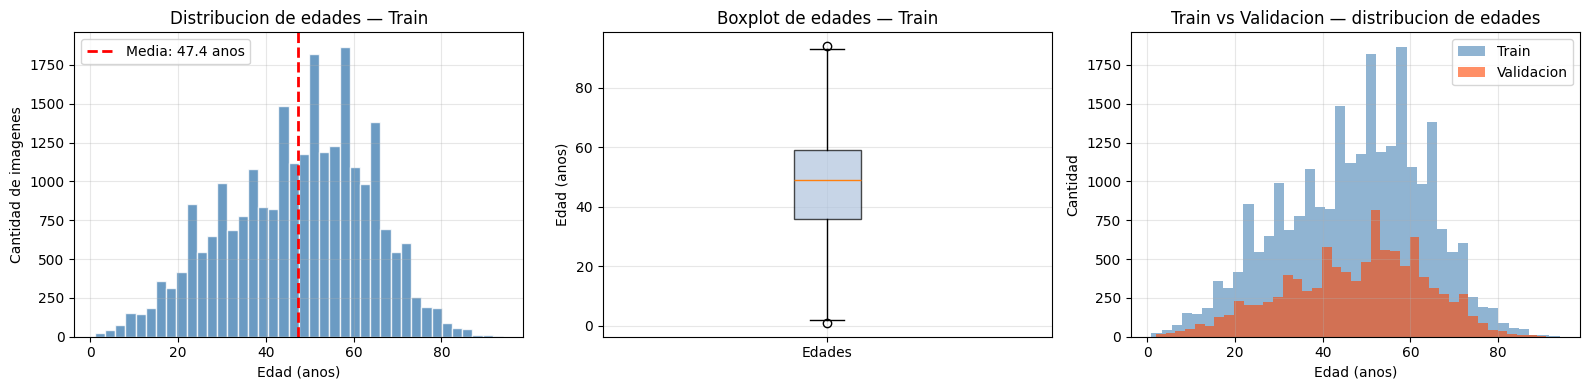


Outliers estadisticos (metodo IQR): 2 imagenes
  Rango normal: [1.5, 93.5] anos


In [ ]:
# ── Calcular baseline y estadisticas ─────────────────────────────────────────
media_edad_train = df_train['edad'].mean()

# Baseline MAE: si siempre predijeras la media, cuanto te equivocarias en promedio
# Esta es la barra minima que el modelo tiene que superar para ser util
baseline_mae = (df_train['edad'] - media_edad_train).abs().mean()

print("=" * 50)
print("ANALISIS DE EDADES — SET DE TRAIN")
print("=" * 50)
print(df_train['edad'].describe().round(2))
print(f"\nMedia de edades (train)  : {media_edad_train:.1f} anos")
print(f"Baseline MAE             : {baseline_mae:.2f} anos")
print(f"  → El modelo debe tener MAE < {baseline_mae:.2f} para ser util")

# ── Visualizaciones ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Grafica 1: Histograma de distribucion de edades ---
# Muestra cuantas imagenes hay por rango de edad.
# Si hay muchas mas imagenes de ciertos rangos, el modelo aprendera mejor para ellos.
axes[0].hist(df_train['edad'], bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(media_edad_train, color='red', linestyle='--', lw=2,
                label=f'Media: {media_edad_train:.1f} anos')
axes[0].set_title('Distribucion de edades — Train')
axes[0].set_xlabel('Edad (anos)')
axes[0].set_ylabel('Cantidad de imagenes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Boxplot para detectar outliers ---
# Los puntos fuera de los bigotes son outliers estadisticos.
# El filtro EDAD_MINIMA/MAXIMA ya deberia haberlos eliminado, pero confirmamos.
axes[1].boxplot(df_train['edad'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', alpha=0.7))
axes[1].set_title('Boxplot de edades — Train')
axes[1].set_ylabel('Edad (anos)')
axes[1].set_xticklabels(['Edades'])
axes[1].grid(True, alpha=0.3)

# --- Grafica 3: Train vs Validacion ---
# Verificamos que ambos conjuntos tengan distribuciones similares de edad.
# Si train tiene mas jovenes que val, el modelo aprenderia para jovenes
# pero seria evaluado en una distribucion diferente — resultados poco confiables.
axes[2].hist(df_train['edad'], bins=40, alpha=0.6, label='Train',      color='steelblue')
axes[2].hist(df_val['edad'],   bins=40, alpha=0.6, label='Validacion', color='orangered')
axes[2].set_title('Train vs Validacion — distribucion de edades')
axes[2].set_xlabel('Edad (anos)')
axes[2].set_ylabel('Cantidad')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(ruta_checkpoints / 'analisis_edades.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Reporte de outliers con metodo IQR ────────────────────────────────────────
# IQR (rango intercuartilico) es el metodo estadistico estandar para outliers:
# cualquier valor < Q1 - 1.5*IQR o > Q3 + 1.5*IQR se considera outlier
Q1  = df_train['edad'].quantile(0.25)
Q3  = df_train['edad'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_train[(df_train['edad'] < Q1 - 1.5*IQR) | (df_train['edad'] > Q3 + 1.5*IQR)]
print(f"\nOutliers estadisticos (metodo IQR): {len(outliers):,} imagenes")
print(f"  Rango normal: [{Q1 - 1.5*IQR:.1f}, {Q3 + 1.5*IQR:.1f}] anos")

## Celda 8 — Generadores de imagenes

`ImageDataGenerator` resuelve esto cargando las imagenes en lotes pequeños
directo desde disco, justo cuando el modelo las necesita.

**`class_mode='raw'` — LA diferencia clave con el NB02:**
- NB02 usaba `class_mode='binary'` → el target es 0 o 1 (clasificacion)
- Este notebook usa `class_mode='raw'` → el target es el numero exacto
  de la columna `y_col`, sin transformacion (ej: 47.0 anos)
Sin `class_mode='raw'`, Keras converteria la edad a una categoria
y el modelo no aprenderia nada correcto.

In [ ]:
# ── Generador para TRAIN (con augmentation ligero) ─────────────────────────────
# rescale=1./255: convierte pixeles de [0,255] a [0,1]
# Las redes neuronales entrenan mucho mejor con valores en ese rango pequeno.
# rotation_range=10: rotaciones de hasta +/-10 grados aleatoriamente
# zoom_range=0.1: zoom aleatorio hasta 10% — simula distintas distancias al equipo
# horizontal_flip: voltea horizontalmente — valido en radiografias de torax
gen_train = ImageDataGenerator(
    rescale            = 1.0 / 255.0,
    rotation_range     = 10,
    zoom_range         = 0.10,
    horizontal_flip    = True,
    width_shift_range  = 0.05,
    height_shift_range = 0.05
)

# ── Generador para VALIDACION y TEST (solo normalizacion) ─────────────────────
# Para evaluar queremos ver las imagenes tal como son, sin modificarlas.
# Si augmentaramos en evaluacion, los resultados cambiarian en cada corrida.
gen_eval = ImageDataGenerator(rescale=1.0 / 255.0)

# ── Configuracion comun a los 3 flujos ────────────────────────────────────────
# x_col: columna con la ruta de la imagen
# y_col: columna con el target (lo que el modelo debe aprender a predecir)
# class_mode='raw': OBLIGATORIO para regresion. Devuelve el valor numerico exacto.
#   En clasificacion se usa 'binary' o 'categorical'. En regresion SIEMPRE 'raw'.
# color_mode='rgb': 3 canales. Las rx son grises pero DenseNet121 espera 3 canales.
config = dict(
    x_col       = 'ruta_completa',
    y_col       = 'edad',
    target_size = (TAMANO_IMAGEN, TAMANO_IMAGEN),
    batch_size  = BATCH_SIZE,
    class_mode  = 'raw',
    color_mode  = 'rgb',
)

# ── Flujo de TRAIN ─────────────────────────────────────────────────────────────
# shuffle=True: mezcla el orden en cada epoch — el modelo no ve siempre el mismo orden
flujo_train = gen_train.flow_from_dataframe(
    dataframe = df_train,
    shuffle   = True,
    seed      = SEMILLA,
    **config
)

# ── Flujo de VALIDACION ───────────────────────────────────────────────────────
# shuffle=False: orden fijo para que los resultados sean reproducibles
flujo_val = gen_eval.flow_from_dataframe(
    dataframe = df_val,
    shuffle   = False,
    **config
)

# ── Flujo de TEST ─────────────────────────────────────────────────────────────
flujo_test = gen_eval.flow_from_dataframe(
    dataframe = df_test,
    shuffle   = False,
    **config
)

print("Flujos creados:")
print(f"  Train      : {flujo_train.n:,} imagenes  |  {flujo_train.n // BATCH_SIZE} batches/epoch")
print(f"  Validacion : {flujo_val.n:,} imagenes   |  {flujo_val.n // BATCH_SIZE} batches/epoch")
print(f"  Test       : {flujo_test.n:,} imagenes   |  {flujo_test.n // BATCH_SIZE} batches")

Found 25000 validated image filenames.
Found 10148 validated image filenames.
Found 10173 validated image filenames.
Flujos creados:
  Train      : 25,000 imagenes  |  781 batches/epoch
  Validacion : 10,148 imagenes   |  317 batches/epoch
  Test       : 10,173 imagenes   |  317 batches


## Celda 9 — Cargar backbone y construir modelo de regresion

**El corazon del transfer learning.**

El backbone del NB02 tiene salida `(None, 7, 7, 1024)` — la capa `bn`
(batch normalization final de DenseNet121). Su ultima capa NO es GAP.
Verificarlo antes de agregarlo para no poner dos seguidos.

**Arquitectura de la cabeza de regresion:**
```
backbone (7, 7, 1024)
    ↓
GlobalAveragePooling2D → (1024,)    ← promedia los 7x7 detectores
    ↓
Dense(256, relu) → (256,)           ← combina patrones aprendidos
    ↓
Dropout(0.3)                        ← apaga 30% de neuronas en train
    ↓
Dense(1, linear) → (1,)             ← UN numero: la edad predicha
```

**Por que 'linear' al final?**
- sigmoid: limita a [0,1] → no sirve para predecir edades
- relu: limita a [0, infinito) → podria funcionar pero corta valores negativos
- linear: sin limite → la neurona devuelve su valor directo.
  El modelo aprende a que ese valor este en el rango correcto de edades.

In [ ]:
# ── Cargar backbone pre-entrenado ──────────────────────────────────────────────
# compile=False: no recompilamos el backbone, lo vamos a modificar
backbone = load_model(str(ruta_backbone), compile=False)

print("Backbone cargado correctamente.")
print(f"  Entrada      : {backbone.input_shape}")
print(f"  Salida       : {backbone.output_shape}")
print(f"  Capas totales: {len(backbone.layers)}")
print(f"  Ultima capa  : '{backbone.layers[-1].name}' (tipo: {type(backbone.layers[-1]).__name__})")

# ── Verificar si el backbone ya tiene GlobalAveragePooling2D ──────────────────
# La guia de Olimpia pide verificar esto antes de agregar el GAP.
# Output shape 2D (batch, features) = ya tiene GAP incluido
# Output shape 4D (batch, h, w, ch) = no tiene GAP, hay que agregarlo
ya_tiene_gap = (len(backbone.output_shape) == 2)

if ya_tiene_gap:
    print("\n  El backbone YA incluye GlobalAveragePooling2D. No se agrega otro.")
else:
    print("\n  El backbone NO tiene GlobalAveragePooling2D. Se agregara en la cabeza.")

# ── Congelar el backbone — FASE 1 ─────────────────────────────────────────────
# trainable=False = estos pesos NO se modifican durante el entrenamiento.
# La cabeza nueva aprende a interpretar los features del backbone sin cambiarlo.
backbone.trainable = False

# ── Construir cabeza de regresion ─────────────────────────────────────────────
x = backbone.output

# Agregar GlobalAveragePooling2D solo si el backbone no lo tiene
if not ya_tiene_gap:
    # Colapsa (7, 7, 1024) → (1024,)
    # Toma el promedio espacial de cada uno de los 1024 mapas de caracteristicas.
    # Ventaja sobre Flatten: mismo tamano de vector sin importar la entrada,
    # y con muchos menos parametros (50k vs 1024).
    x = layers.GlobalAveragePooling2D(name="gap")(x)

# Dense(256): 256 neuronas totalmente conectadas.
# activation='relu': Rectified Linear Unit — pone en 0 los valores negativos.
# Es la activacion mas usada en capas intermedias: estable y computacionalmente barata.
x = layers.Dense(256, activation='relu', name="fc_256")(x)

# Dropout(0.3): durante el entrenamiento apaga aleatoriamente el 30% de neuronas.
# Esto evita que el modelo dependa de neuronas individuales y lo obliga a
# aprender representaciones mas robustas. Se desactiva automaticamente al predecir.
x = layers.Dropout(0.3, name="dropout")(x)

# Dense(1, linear): capa de salida de regresion.
# - 1 neurona: queremos UN numero como salida
# - activation='linear': sin transformacion — devuelve el valor directo
salida = layers.Dense(1, activation='linear', name="edad_predicha")(x)

# ── Ensamblar modelo completo ──────────────────────────────────────────────────
# Model(inputs, outputs) conecta el backbone con la cabeza nueva
modelo = Model(
    inputs  = backbone.input,
    outputs = salida,
    name    = "modelo_regresion_edad"
)

# Resumen de parametros
params_total     = modelo.count_params()
params_train     = sum(tf.size(w).numpy() for w in modelo.trainable_weights)
params_frozen    = params_total - params_train

print(f"\nModelo ensamblado:")
print(f"  Parametros totales    : {params_total:,}")
print(f"  Entrenables (cabeza)  : {params_train:,}")
print(f"  Congelados (backbone) : {params_frozen:,}")

Backbone cargado correctamente.
  Entrada      : (None, 224, 224, 3)
  Salida       : (None, 7, 7, 1024)
  Capas totales: 426
  Ultima capa  : 'bn' (tipo: BatchNormalization)

  El backbone NO tiene GlobalAveragePooling2D. Se agregara en la cabeza.

Modelo ensamblado:
  Parametros totales    : 7,300,161
  Entrenables (cabeza)  : 262,657
  Congelados (backbone) : 7,037,504


## Celda 10 — Compilar y entrenar FASE 1 (backbone congelado)

**Compilar** = configurar como va a aprender el modelo.

Para regresion necesitamos:

- **Loss `mae`**: Mean Absolute Error — promedio de |predicho - real| en anos.
  Ejemplo: predice 45, real es 50 → error = 5 anos.
  Se elige MAE sobre MSE porque esta en las mismas unidades que el target (anos),
  lo que hace que el valor sea directamente interpretable.

- **Metrica RMSE**: Root Mean Squared Error — como MAE pero penaliza mas los
  errores grandes. Si el modelo se equivoca 20 anos en algunos casos,
  el RMSE lo reflejara mas que el MAE.

**Callbacks — herramientas que corren automaticamente en cada epoch:**
- `ModelCheckpoint`: guarda el modelo solo cuando mejora
- `EarlyStopping`: para el entrenamiento si no mejora en 5 epochs seguidos
- `ReduceLROnPlateau`: reduce el lr a la mitad si el modelo se estanca

In [ ]:
# ── Funcion que reinicia el generador automaticamente entre epochs ─────────────
# El problema: flow_from_dataframe se agota despues de un epoch y Keras
# no lo resetea solo. Este wrapper lo reinicia cada vez que se queda sin datos,
# haciendo que el flujo sea infinito para que model.fit() nunca se quede sin batches.
def generador_infinito(flujo):
    while True:
        flujo.reset()
        for batch in flujo:
            yield batch

modelo.compile(
    optimizer = Adam(learning_rate=LR_FASE_1),
    loss      = 'mae',
    metrics   = ['mae', RootMeanSquaredError(name='rmse')]
)
print(f"Modelo compilado para FASE 1 (lr={LR_FASE_1})")

checkpoint = ModelCheckpoint(
    filepath       = str(ruta_modelo),
    monitor        = 'val_mae',
    save_best_only = True,
    mode           = 'min',
    verbose        = 1
)
early_stop = EarlyStopping(
    monitor              = 'val_mae',
    patience             = 5,
    mode                 = 'min',
    restore_best_weights = True,
    verbose              = 1
)
reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_mae',
    factor   = 0.5,
    patience = 3,
    mode     = 'min',
    min_lr   = 1e-7,
    verbose  = 1
)

# Calcular steps una sola vez
steps_train = flujo_train.n // BATCH_SIZE
steps_val   = flujo_val.n   // BATCH_SIZE

print("\nIniciando FASE 1: backbone congelado, entrenando solo la cabeza nueva...")
print(f"  Steps por epoch (train): {steps_train}")
print(f"  Steps por epoch (val)  : {steps_val}")
print("-" * 60)

historia_f1 = modelo.fit(
    generador_infinito(flujo_train),   # ← generador infinito
    epochs           = EPOCHS_FASE_1,
    steps_per_epoch  = steps_train,
    validation_data  = generador_infinito(flujo_val),   # ← igual para val
    validation_steps = steps_val,
    callbacks        = [checkpoint, early_stop, reduce_lr]
)

print(f"\nFASE 1 completada.")
print(f"  Mejor val_MAE  : {min(historia_f1.history['val_mae']):.2f} anos")
print(f"  Mejor val_RMSE : {min(historia_f1.history['val_rmse']):.2f} anos")


Modelo compilado para FASE 1 (lr=0.001)

Iniciando FASE 1: backbone congelado, entrenando solo la cabeza nueva...
  Steps por epoch (train): 781
  Steps por epoch (val)  : 317
------------------------------------------------------------
Epoch 1/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - loss: 13.0370 - mae: 13.0370 - rmse: 16.7063
Epoch 1: val_mae improved from None to 9.28455, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 434s 521ms/step - loss: 10.5605 - mae: 10.5605 - rmse: 13.6185 - val_loss: 9.2846 - val_mae: 9.2846 - val_rmse: 11.6463 - learning_rate: 0.0010
Epoch 2/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - loss: 9.2858 - mae: 9.2858 - rmse: 11.7596
Epoch 2: val_mae improved from 9.28455 to 8.73959, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 425s 529ms/step - loss: 9.2658 - mae: 9.2658 - rmse: 11.7106 - val_loss: 8.7396 - val_mae: 8.7396 - val_rmse: 11.0166 - learning_rate: 0.0010
Epoch 3/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - loss: 9.0630 - mae: 9.0630 - rmse: 11.4490
Epoch 3: val_mae improved from 8.73959 to 8.40526, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 385s 493ms/step - loss: 9.0619 - mae: 9.0619 - rmse: 11.4541 - val_loss: 8.4053 - val_mae: 8.4053 - val_rmse: 10.6133 - learning_rate: 0.0010
Epoch 4/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - loss: 8.9915 - mae: 8.9915 - rmse: 11.3225
Epoch 4: val_mae did not improve from 8.40526
781/781 ━━━━━━━━━━━━━━━━━━━━ 395s 507ms/step - loss: 9.0072 - mae: 9.0072 - rmse: 11.3548 - val_loss: 8.4678 - val_mae: 8.4678 - val_rmse: 10.6709 - learning_rate: 0.0010
Epoch 5/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - loss: 9.0240 - mae: 9.0240 - rmse: 11.4026
Epoch 5: val_mae improved from 8.40526 to 8.15382, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 383s 491ms/step - loss: 8.9641 - mae: 8.9641 - rmse: 11.3195 - val_loss: 8.1538 - val_mae: 8.1538 - val_rmse: 10.3419 - learning_rate: 0.0010
Epoch 6/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - loss: 8.9700 - mae: 8.9700 - rmse: 11.3268
Epoch 6: val_mae improved from 8.15382 to 8.05957, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 358s 459ms/step - loss: 8.9009 - mae: 8.9009 - rmse: 11.2404 - val_loss: 8.0596 - val_mae: 8.0596 - val_rmse: 10.2158 - learning_rate: 0.0010
Epoch 7/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - loss: 8.8329 - mae: 8.8329 - rmse: 11.1966
Epoch 7: val_mae improved from 8.05957 to 8.05535, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 7: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 381s 488ms/step - loss: 8.8265 - mae: 8.8265 - rmse: 11.1658 - val_loss: 8.0553 - val_mae: 8.0553 - val_rmse: 10.2067 - learning_rate: 0.0010
Epoch 8/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - loss: 8.8308 - mae: 8.8308 - rmse: 11.1976
Epoch 8: val_mae did not improve from 8.05535
781/781 ━━━━━━━━━━━━━━━━━━━━ 357s 458ms/step - loss: 8.8172 - mae: 8.8172 - rmse: 11.1597 - val_loss: 8.0769 - val_mae: 8.0769 - val_rmse: 10.2405 - learning_rate: 0.0010
Epoch 9/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - loss: 8.6913 - mae: 8.6913 - rmse: 11.0095
Epoch 9: val_mae improved from 8.05535 to 7.96387, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 359s 461ms/step - loss: 8.7631 - mae: 8.7631 - rmse: 11.0805 - val_loss: 7.9639 - val_mae: 7.9639 - val_rmse: 10.0831 - learning_rate: 0.0010
Epoch 10/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - loss: 8.7705 - mae: 8.7705 - rmse: 11.0765
Epoch 10: val_mae improved from 7.96387 to 7.91391, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 10: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 359s 460ms/step - loss: 8.7991 - mae: 8.7991 - rmse: 11.1163 - val_loss: 7.9139 - val_mae: 7.9139 - val_rmse: 10.0526 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.

FASE 1 completada.
  Mejor val_MAE  : 7.91 anos
  Mejor val_RMSE : 10.05 anos


## Celda 11 — FASE 2: Fine-tuning del backbone

Ahora que la cabeza esta estabilizada, descongelamos las ultimas capas
del backbone para que se especialicen en radiografias de edad.

**Por que solo las ULTIMAS capas?**

Las capas de una red profunda aprenden distintas cosas segun su posicion:
- Primeras capas: bordes, texturas — utiles para CUALQUIER imagen
- Capas medias: formas, estructuras — mas especifico al tipo de imagen
- Ultimas capas: patrones de alto nivel — muy especifico del dominio

Las primeras capas ya son buenas genericas — no tiene sentido cambiarlas.
Las ultimas necesitan adaptarse a 'leer' las marcas del envejecimiento
en radiografias especificamente.

**ADVERTENCIA: learning rate muy pequeno en fase 2.**
Con lr=0.001 como en fase 1, destruiriamos lo que el backbone aprendio.
Con lr=0.00001 hacemos ajustes minimos y sutiles.

In [ ]:
# ── Descongelar las ultimas 50 capas del backbone ─────────────────────────────
# Primero habilitamos el backbone para poder modificar capas individuales
backbone.trainable = True

# Luego congelamos todo EXCEPTO las ultimas 50 capas.
# backbone.layers[:-50] = todas las capas menos las 50 ultimas → congeladas
# backbone.layers[-50:] = las 50 ultimas → quedan entrenables
CAPAS_A_DESCONGELAR = 50
for capa in backbone.layers[:-CAPAS_A_DESCONGELAR]:
    capa.trainable = False

params_f2 = sum(tf.size(w).numpy() for w in modelo.trainable_weights)
print(f"FASE 2: {params_f2:,} parametros entrenables")
print(f"  (ultimas {CAPAS_A_DESCONGELAR} capas del backbone + toda la cabeza)")

# ── IMPORTANTE: Recompilar despues de cambiar trainable ───────────────────────
# Si no recompilamos, el cambio en trainable no tiene efecto en el optimizer.
# Usamos LR muy pequeno para ajustes minimos sobre el backbone.
modelo.compile(
    optimizer = Adam(learning_rate=LR_FASE_2),
    loss      = 'mae',
    metrics   = ['mae', RootMeanSquaredError(name='rmse')]
)
print(f"Modelo recompilado para FASE 2 (lr={LR_FASE_2})")

# ── ENTRENAR FASE 2 ────────────────────────────────────────────────────────────
print("\nIniciando FASE 2: fine-tuning de las ultimas capas del backbone...")
print("-" * 60)

historia_f2 = modelo.fit(
    generador_infinito(flujo_train),
    epochs           = EPOCHS_FASE_2,
    steps_per_epoch  = flujo_train.n // BATCH_SIZE,
    validation_data  = generador_infinito(flujo_val),
    validation_steps = flujo_val.n // BATCH_SIZE,
    callbacks        = [checkpoint, early_stop, reduce_lr]
)

print(f"\nFASE 2 completada.")
print(f"  Mejor val_MAE  : {min(historia_f2.history['val_mae']):.2f} anos")
print(f"  Mejor val_RMSE : {min(historia_f2.history['val_rmse']):.2f} anos")

FASE 2: 1,339,905 parametros entrenables
  (ultimas 50 capas del backbone + toda la cabeza)
Modelo recompilado para FASE 2 (lr=1e-05)

Iniciando FASE 2: fine-tuning de las ultimas capas del backbone...
------------------------------------------------------------
Epoch 1/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - loss: 8.6965 - mae: 8.6965 - rmse: 11.0119
Epoch 1: val_mae did not improve from 7.91391
781/781 ━━━━━━━━━━━━━━━━━━━━ 419s 487ms/step - loss: 8.6251 - mae: 8.6251 - rmse: 10.9152 - val_loss: 8.0516 - val_mae: 8.0516 - val_rmse: 10.1822 - learning_rate: 1.0000e-05
Epoch 2/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - loss: 8.4283 - mae: 8.4283 - rmse: 10.6889
Epoch 2: val_mae improved from 7.91391 to 7.69366, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 384s 463ms/step - loss: 8.4331 - mae: 8.4331 - rmse: 10.6767 - val_loss: 7.6937 - val_mae: 7.6937 - val_rmse: 9.7392 - learning_rate: 1.0000e-05
Epoch 3/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - loss: 8.2433 - mae: 8.2433 - rmse: 10.4649
Epoch 3: val_mae improved from 7.69366 to 7.53356, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 365s 468ms/step - loss: 8.2206 - mae: 8.2206 - rmse: 10.4344 - val_loss: 7.5336 - val_mae: 7.5336 - val_rmse: 9.5381 - learning_rate: 1.0000e-05
Epoch 4/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - loss: 8.2204 - mae: 8.2204 - rmse: 10.3971
Epoch 4: val_mae did not improve from 7.53356
781/781 ━━━━━━━━━━━━━━━━━━━━ 364s 466ms/step - loss: 8.1906 - mae: 8.1906 - rmse: 10.3440 - val_loss: 7.6329 - val_mae: 7.6329 - val_rmse: 9.6500 - learning_rate: 1.0000e-05
Epoch 5/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - loss: 8.1535 - mae: 8.1535 - rmse: 10.3637
Epoch 5: val_mae improved from 7.53356 to 7.35119, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 359s 460ms/step - loss: 8.0587 - mae: 8.0587 - rmse: 10.2132 - val_loss: 7.3512 - val_mae: 7.3512 - val_rmse: 9.3152 - learning_rate: 1.0000e-05
Epoch 6/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - loss: 7.9004 - mae: 7.9004 - rmse: 10.0023
Epoch 6: val_mae did not improve from 7.35119
781/781 ━━━━━━━━━━━━━━━━━━━━ 354s 454ms/step - loss: 7.8992 - mae: 7.8992 - rmse: 10.0137 - val_loss: 7.5373 - val_mae: 7.5373 - val_rmse: 9.5311 - learning_rate: 1.0000e-05
Epoch 7/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - loss: 7.8854 - mae: 7.8854 - rmse: 10.0204
Epoch 7: val_mae did not improve from 7.35119
781/781 ━━━━━━━━━━━━━━━━━━━━ 357s 457ms/step - loss: 7.8233 - mae: 7.8233 - rmse: 9.9263 - val_loss: 7.4610 - val_mae: 7.4610 - val_rmse: 9.4335 - learning_rate: 1.0000e-05
Epoch 8/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - loss: 7.7284 - mae: 7.7284 - rms


Epoch 8: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 366s 469ms/step - loss: 7.7498 - mae: 7.7498 - rmse: 9.8351 - val_loss: 7.0304 - val_mae: 7.0304 - val_rmse: 8.9275 - learning_rate: 1.0000e-05
Epoch 9/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - loss: 7.6551 - mae: 7.6551 - rmse: 9.6879
Epoch 9: val_mae did not improve from 7.03043
781/781 ━━━━━━━━━━━━━━━━━━━━ 362s 464ms/step - loss: 7.6390 - mae: 7.6390 - rmse: 9.6899 - val_loss: 7.2492 - val_mae: 7.2492 - val_rmse: 9.1868 - learning_rate: 1.0000e-05
Epoch 10/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - loss: 7.6203 - mae: 7.6203 - rmse: 9.7104
Epoch 10: val_mae improved from 7.03043 to 6.93545, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 10: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 384s 492ms/step - loss: 7.5707 - mae: 7.5707 - rmse: 9.6273 - val_loss: 6.9354 - val_mae: 6.9354 - val_rmse: 8.8118 - learning_rate: 1.0000e-05
Epoch 11/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - loss: 7.5059 - mae: 7.5059 - rmse: 9.5032
Epoch 11: val_mae did not improve from 6.93545
781/781 ━━━━━━━━━━━━━━━━━━━━ 366s 469ms/step - loss: 7.5556 - mae: 7.5556 - rmse: 9.5683 - val_loss: 7.1264 - val_mae: 7.1264 - val_rmse: 9.0148 - learning_rate: 1.0000e-05
Epoch 12/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - loss: 7.3962 - mae: 7.3962 - rmse: 9.3813
Epoch 12: val_mae did not improve from 6.93545
781/781 ━━━━━━━━━━━━━━━━━━━━ 363s 465ms/step - loss: 7.4567 - mae: 7.4567 - rmse: 9.4597 - val_loss: 6.9853 - val_mae: 6.9853 - val_rmse: 8.8657 - learning_rate: 1.0000e-05
Epoch 13/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - loss: 7.4454 - mae: 7.4454 - r


Epoch 13: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 368s 472ms/step - loss: 7.3875 - mae: 7.3875 - rmse: 9.3894 - val_loss: 6.7618 - val_mae: 6.7618 - val_rmse: 8.6114 - learning_rate: 1.0000e-05
Epoch 14/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - loss: 7.4093 - mae: 7.4093 - rmse: 9.3902
Epoch 14: val_mae improved from 6.76185 to 6.74041, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5



Epoch 14: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 365s 468ms/step - loss: 7.3614 - mae: 7.3614 - rmse: 9.3389 - val_loss: 6.7404 - val_mae: 6.7404 - val_rmse: 8.5852 - learning_rate: 1.0000e-05
Epoch 15/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - loss: 7.2215 - mae: 7.2215 - rmse: 9.1823
Epoch 15: val_mae did not improve from 6.74041
781/781 ━━━━━━━━━━━━━━━━━━━━ 356s 456ms/step - loss: 7.2694 - mae: 7.2694 - rmse: 9.2393 - val_loss: 6.9120 - val_mae: 6.9120 - val_rmse: 8.7770 - learning_rate: 1.0000e-05
Epoch 16/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - loss: 7.2653 - mae: 7.2653 - rmse: 9.1952
Epoch 16: val_mae did not improve from 6.74041
781/781 ━━━━━━━━━━━━━━━━━━━━ 361s 463ms/step - loss: 7.2558 - mae: 7.2558 - rmse: 9.1877 - val_loss: 6.7697 - val_mae: 6.7697 - val_rmse: 8.6192 - learning_rate: 1.0000e-05
Epoch 17/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - loss: 7.1876 - mae: 7.1876 - r


Epoch 19: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_regresion.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 360s 462ms/step - loss: 7.1800 - mae: 7.1800 - rmse: 9.0958 - val_loss: 6.6431 - val_mae: 6.6431 - val_rmse: 8.4723 - learning_rate: 5.0000e-06
Epoch 20/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - loss: 7.0866 - mae: 7.0866 - rmse: 9.0265
Epoch 20: val_mae did not improve from 6.64307
781/781 ━━━━━━━━━━━━━━━━━━━━ 356s 457ms/step - loss: 7.1130 - mae: 7.1130 - rmse: 9.0496 - val_loss: 6.7973 - val_mae: 6.7973 - val_rmse: 8.6484 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 19.

FASE 2 completada.
  Mejor val_MAE  : 6.64 anos
  Mejor val_RMSE : 8.47 anos


## Celda 12 — Curvas de entrenamiento con linea baseline

Concatenamos las historias de ambas fases y graficamos la trayectoria completa.

**La linea de baseline** es el aporte especifico de la guia de Olimpia.
Representa el MAE que obtendria un modelo tonto que siempre predice la media.
Si nuestras curvas quedan por encima de esa linea, no aprendimos nada mejor
que predecir siempre el promedio.

**Como interpretar las curvas:**
- Ambas curvas bajan y se estabilizan bajo el baseline → entrenamiento exitoso
- Train baja pero val sube → overfitting (memorizo, no aprendio)
- Ambas curvas se estancan sobre el baseline → underfitting (no aprendio nada)

Curvas guardadas en: /content/drive/MyDrive/Vena/checkpoints/curvas_entrenamiento_regresion.png


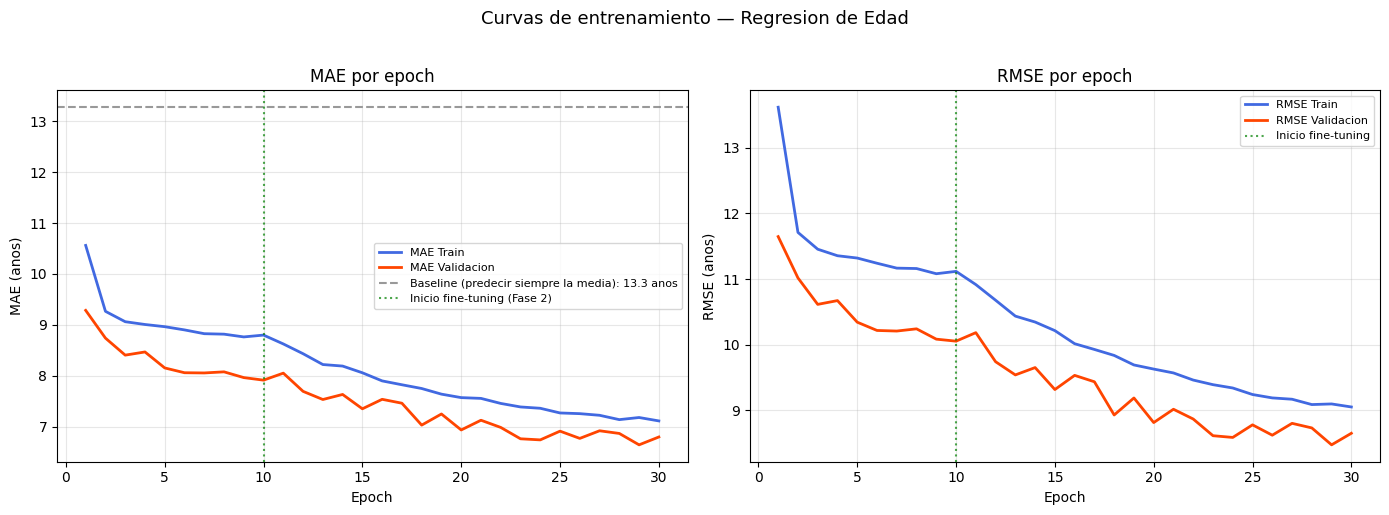


Resumen del entrenamiento:
  Mejor val_MAE  : 6.64 anos  (epoch 29)
  Mejor val_RMSE : 8.47 anos
  Baseline MAE   : 13.28 anos

  OK: El modelo supera el baseline por 6.63 anos.
  Referencia del curso: 8-12 anos = razonable | <8 = excelente


In [ ]:
# ── Concatenar historiales de ambas fases ──────────────────────────────────────
# history.history es un diccionario: {'mae': [...lista por epoch...], 'val_mae': [...]}
# Unimos las listas con el operador + para ver la trayectoria completa
mae_train  = historia_f1.history['mae']      + historia_f2.history['mae']
mae_val    = historia_f1.history['val_mae']  + historia_f2.history['val_mae']
rmse_train = historia_f1.history['rmse']     + historia_f2.history['rmse']
rmse_val   = historia_f1.history['val_rmse'] + historia_f2.history['val_rmse']
epochs_eje = list(range(1, len(mae_train) + 1))
fin_fase1  = len(historia_f1.history['mae'])  # Epoch donde termina fase 1

# ── Graficar ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: MAE por epoch ---
axes[0].plot(epochs_eje, mae_train, label='MAE Train',      color='royalblue', lw=2)
axes[0].plot(epochs_eje, mae_val,   label='MAE Validacion', color='orangered', lw=2)

# Linea de baseline — especificada en la guia de Olimpia
# Un modelo util debe quedar POR DEBAJO de esta linea horizontal
axes[0].axhline(
    y         = baseline_mae,
    color     = 'gray',
    linestyle = '--',
    alpha     = 0.8,
    label     = f'Baseline (predecir siempre la media): {baseline_mae:.1f} anos'
)

# Linea vertical marcando donde empieza el fine-tuning
axes[0].axvline(
    x         = fin_fase1,
    color     = 'green',
    linestyle = ':',
    alpha     = 0.7,
    label     = 'Inicio fine-tuning (Fase 2)'
)

axes[0].set_title('MAE por epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE (anos)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: RMSE por epoch ---
# RMSE penaliza mas los errores grandes, por eso siempre es mayor que MAE
axes[1].plot(epochs_eje, rmse_train, label='RMSE Train',      color='royalblue', lw=2)
axes[1].plot(epochs_eje, rmse_val,   label='RMSE Validacion', color='orangered', lw=2)
axes[1].axvline(x=fin_fase1, color='green', linestyle=':', alpha=0.7, label='Inicio fine-tuning')
axes[1].set_title('RMSE por epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE (anos)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de entrenamiento — Regresion de Edad', fontsize=13, y=1.02)
plt.tight_layout()

ruta_curvas = ruta_checkpoints / 'curvas_entrenamiento_regresion.png'
plt.savefig(str(ruta_curvas), dpi=150, bbox_inches='tight')
print(f"Curvas guardadas en: {ruta_curvas}")
plt.show()

# ── Resumen e interpretacion automatica ───────────────────────────────────────
mejor_mae_val  = min(mae_val)
mejor_rmse_val = min(rmse_val)
mejor_epoch    = mae_val.index(mejor_mae_val) + 1

print(f"\nResumen del entrenamiento:")
print(f"  Mejor val_MAE  : {mejor_mae_val:.2f} anos  (epoch {mejor_epoch})")
print(f"  Mejor val_RMSE : {mejor_rmse_val:.2f} anos")
print(f"  Baseline MAE   : {baseline_mae:.2f} anos")

if mejor_mae_val < baseline_mae:
    print(f"\n  OK: El modelo supera el baseline por {baseline_mae - mejor_mae_val:.2f} anos.")
    print(f"  Referencia del curso: 8-12 anos = razonable | <8 = excelente")
else:
    print(f"\n  ALERTA: El modelo NO supera el baseline.")
    print(f"  Revisar: datos de entrada, learning rate, o aumentar EPOCHS_FASE_1.")

## Celda 13 — Evaluacion rapida en test y reporte final

Cargamos el mejor modelo guardado por el checkpoint y hacemos una evaluacion
preliminar sobre el test set.

Incluimos el **R² (coeficiente de determinacion)** que pide la guia:
- R² = 1.0: prediccion perfecta
- R² = 0.0: igual que predecir siempre la media (baseline)
- R² negativo: peor que predecir la media
- Rango tipico para este problema: 0.3 a 0.6

El analisis completo y detallado va en el NB03 de evaluacion.
Esta celda solo confirma que el modelo funciona antes de cerrar la sesion.

Mejor modelo cargado desde checkpoint.
317/317 ━━━━━━━━━━━━━━━━━━━━ 44s 91ms/step - loss: 6.9206 - mae: 6.9206 - rmse: 8.8135
317/317 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step


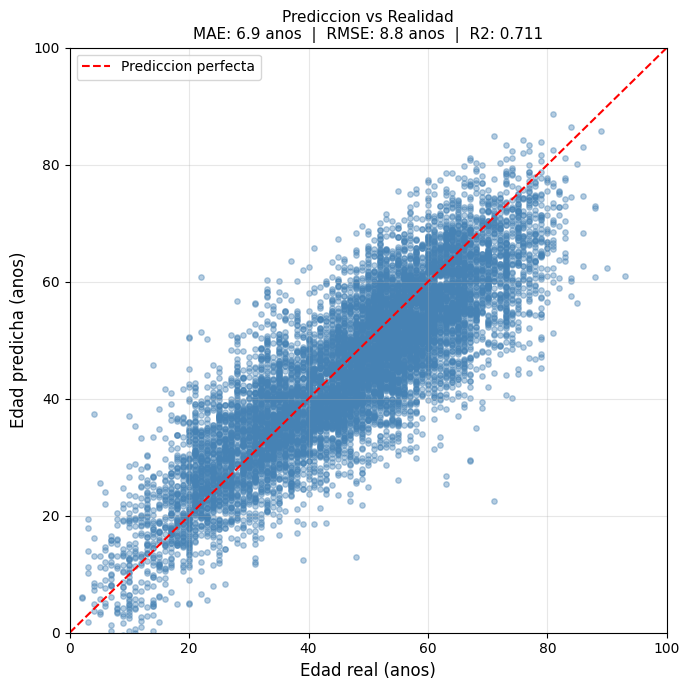


REPORTE FINAL — Regresion de Edad
  MAE en test    : 6.92 anos
                 → en promedio el modelo se equivoca 6.9 anos
  RMSE en test   : 8.81 anos
                 → errores grandes penalizados mas fuerte
  R2 en test     : 0.711
                 → el modelo explica el 71.1% de la varianza de edad
  Baseline MAE   : 13.28 anos (siempre predecir la media)

Rangos de referencia del curso:
  MAE 8-12 anos → razonable para este problema
  MAE < 8 anos  → excelente con Colab gratuito
  R2  0.3-0.6   → tipico en literatura medica

Archivos generados en checkpoints/:
  analisis_edades.png                                 (0.1 MB)
  backbone_densenet121.h5                             (28.1 MB)
  curvas_entrenamiento_clasificacion.png              (0.1 MB)
  curvas_entrenamiento_regresion.png                  (0.1 MB)
  mejor_modelo_clasificacion.h5                       (39.4 MB)
  mejor_modelo_regresion.h5                           (39.4 MB)
  scatter_test_regresion.png                

In [ ]:
from sklearn.metrics import r2_score

# ── Cargar el mejor modelo desde checkpoint ────────────────────────────────────
# El ModelCheckpoint guardo automaticamente el mejor epoch durante el entrenamiento.
# Lo cargamos para confirmar que evaluar el mejor, no el ultimo.
mejor_modelo = load_model(str(ruta_modelo), compile=False)
mejor_modelo.compile(
    optimizer = 'adam',
    loss      = 'mae',
    metrics   = ['mae', RootMeanSquaredError(name='rmse')]
)
print("Mejor modelo cargado desde checkpoint.")

# ── Evaluacion en test ─────────────────────────────────────────────────────────
# .evaluate() corre el modelo sobre todos los batches del test set
# y devuelve [loss, mae, rmse]
flujo_test.reset()  # Reiniciar el generador al principio
resultados = mejor_modelo.evaluate(
    flujo_test,
    steps   = len(df_test) // BATCH_SIZE,
    verbose = 1
)
test_mae, test_rmse = resultados[1], resultados[2]

# ── Generar predicciones para scatter plot y R² ───────────────────────────────
# .predict() corre el modelo y devuelve un array de predicciones
# .flatten() convierte de shape (N, 1) a (N,) — de columna a vector
flujo_test.reset()
predicciones = mejor_modelo.predict(
    flujo_test,
    steps   = len(df_test) // BATCH_SIZE,
    verbose = 1
).flatten()

# Asegurarse de que las longitudes coincidan (el generador puede dar un batch extra)
edades_reales    = df_test['edad'].values[:len(predicciones)]
edades_predichas = predicciones[:len(edades_reales)]

# R² — coeficiente de determinacion: que porcion de la varianza de edad explica el modelo
# r2_score es de sklearn.metrics — no necesita tensorflow
r2 = r2_score(edades_reales, edades_predichas)

# ── Scatter plot: prediccion vs realidad ──────────────────────────────────────
# Esta es la grafica mas importante para regresion:
# - Eje X: edad real del paciente
# - Eje Y: edad que predijo el modelo
# - Si el modelo fuera perfecto, todos los puntos estarian sobre la diagonal roja
# - Cuanto mas dispersos los puntos, mayor el error
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(edades_reales, edades_predichas, alpha=0.4, s=15, color='steelblue')

# Diagonal de prediccion perfecta
lim = [0, 100]
ax.plot(lim, lim, 'r--', lw=1.5, label='Prediccion perfecta')

ax.set_xlabel('Edad real (anos)',     fontsize=12)
ax.set_ylabel('Edad predicha (anos)', fontsize=12)
ax.set_title(
    f'Prediccion vs Realidad\nMAE: {test_mae:.1f} anos  |  RMSE: {test_rmse:.1f} anos  |  R2: {r2:.3f}',
    fontsize=11
)
ax.legend()
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.grid(True, alpha=0.3)

plt.tight_layout()
ruta_scatter = ruta_checkpoints / 'scatter_test_regresion.png'
plt.savefig(str(ruta_scatter), dpi=150, bbox_inches='tight')
plt.show()

# ── Reporte final completo ─────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("REPORTE FINAL — Regresion de Edad")
print("=" * 55)
print(f"  MAE en test    : {test_mae:.2f} anos")
print(f"                 → en promedio el modelo se equivoca {test_mae:.1f} anos")
print(f"  RMSE en test   : {test_rmse:.2f} anos")
print(f"                 → errores grandes penalizados mas fuerte")
print(f"  R2 en test     : {r2:.3f}")
print(f"                 → el modelo explica el {r2*100:.1f}% de la varianza de edad")
print(f"  Baseline MAE   : {baseline_mae:.2f} anos (siempre predecir la media)")
print()
print("Rangos de referencia del curso:")
print("  MAE 8-12 anos → razonable para este problema")
print("  MAE < 8 anos  → excelente con Colab gratuito")
print("  R2  0.3-0.6   → tipico en literatura medica")
print()
print("Archivos generados en checkpoints/:")
for archivo in sorted(ruta_checkpoints.iterdir()):
    mb = archivo.stat().st_size / 1_048_576
    print(f"  {archivo.name:50s}  ({mb:.1f} MB)")
print()
print("Siguiente paso: ejecutar 03_Evaluacion.ipynb para analisis completo.")